In [ ]:
import pandas as pd

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')
matches_df = pd.read_csv('/content/EDA-IPL/data/matches.csv')

df = pd.merge(deliveries_df, matches_df[['id', 'season']], left_on='match_id', right_on='id', how='left')

display(df.head())


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08


In [13]:
legal_deliveries_mask = ~df['extras_type'].isin(['wides', 'noballs'])


dot_balls_mask = legal_deliveries_mask & (df['total_runs'] == 0)

season_stats = df.groupby('season').agg(
    total_runs=('total_runs', 'sum'),
    total_legal_deliveries=('ball', lambda x: x[legal_deliveries_mask.loc[x.index]].count()),
    total_dot_balls=('ball', lambda x: x[dot_balls_mask.loc[x.index]].count())
)


season_stats['total_legal_overs'] = season_stats['total_legal_deliveries'] / 6


season_stats['average_run_rate'] = season_stats['total_runs'] / season_stats['total_legal_overs']


season_stats['dot_ball_percentage'] = (season_stats['total_dot_balls'] / season_stats['total_legal_deliveries']) * 100


display(season_stats.head())


,total_runs,total_legal_deliveries,total_dot_balls,total_legal_overs,average_run_rate,dot_ball_percentage
season,,,,,,
2007/08,17937,12950,4916,2158.333333,8.310579,37.961390
2009,16353,13095,5119,2182.500000,7.492784,39.091256
2009/10,18883,13938,4996,2323.000000,8.128713,35.844454
2011,21154,16425,6282,2737.500000,7.727489,38.246575
2012,22453,17208,6241,2868.000000,7.828801,36.268015


In [14]:
season_stats['arr_pct_change'] = season_stats['average_run_rate'].pct_change() * 100
season_stats['db_pct_change'] = season_stats['dot_ball_percentage'].pct_change() * 100

correlation_coefficient = season_stats['dot_ball_percentage'].corr(season_stats['average_run_rate'])

print(f"Year-over-year change in Average Run Rate and Dot Ball Percentage:\n{season_stats[['arr_pct_change', 'db_pct_change']].dropna()}")
print(f"\nPearson Correlation Coefficient between Dot Ball Percentage and Average Run Rate: {correlation_coefficient}")

Year-over-year change in Average Run Rate and Dot Ball Percentage:
         arr_pct_change  db_pct_change
season                                
2009          -9.840417       2.976356
2009/10        8.487225      -8.305699
2011          -4.935890       6.701515
2012           1.311060      -5.173170
2013          -1.784920       5.665679
2014           6.690825      -5.449889
2015           2.077984       0.213874
2016          -0.758550      -5.984688
2017           1.209831      -0.522832
2018           2.812758       1.360188
2019          -2.691930       3.482973
2020/21       -1.528092      -2.515087
2021          -2.830277       4.134265
2022           6.054322       2.527980
2023           5.275699      -8.487130
2024           6.310232      -2.964616

Pearson Correlation Coefficient between Dot Ball Percentage and Average Run Rate: -0.790073631398696


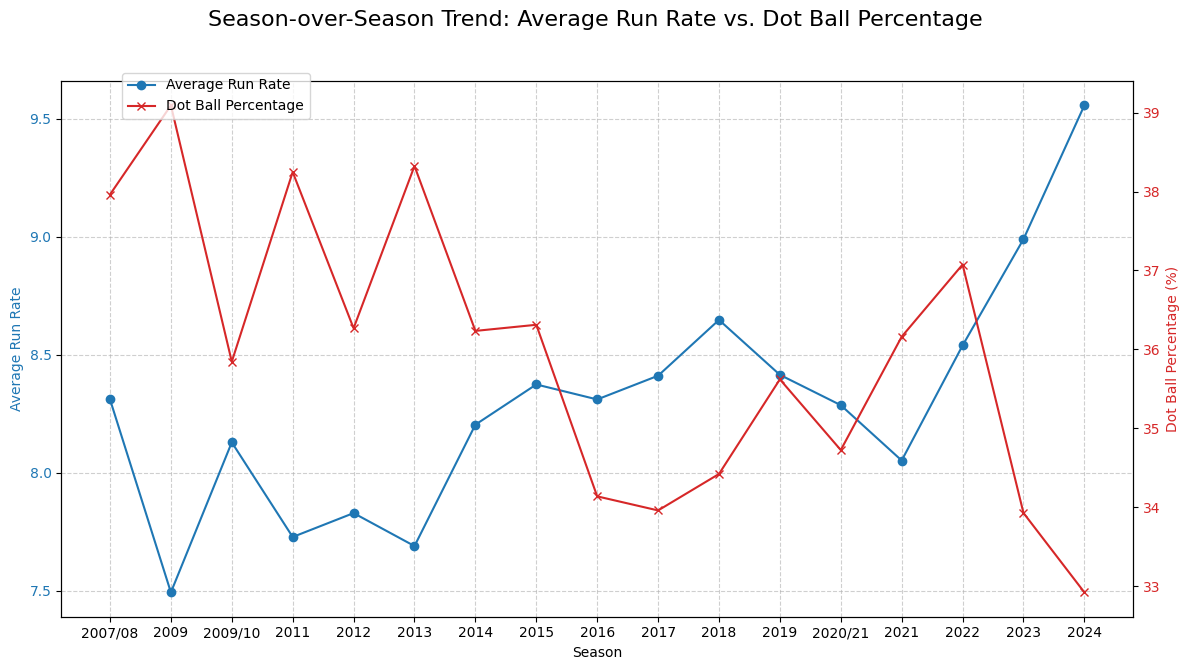

In [15]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Season')
ax1.set_ylabel('Average Run Rate', color='tab:blue')
ax1.plot(season_stats.index.astype(str), season_stats['average_run_rate'], color='tab:blue', marker='o', label='Average Run Rate')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.set_ylabel('Dot Ball Percentage (%)', color='tab:red')
ax2.plot(season_stats.index.astype(str), season_stats['dot_ball_percentage'], color='tab:red', marker='x', label='Dot Ball Percentage')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle('Season-over-Season Trend: Average Run Rate vs. Dot Ball Percentage', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
